In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Food_Delivery_Time_Prediction.csv')

In [ ]:
df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [ ]:
df.tail()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
49995,ORD049996,2025-03-08,14,Saturday,1,0,Fog,Industrial,Industrial,Electric Scooter,...,1,Medium,25,33.67,Long,Low,4,28.6,Normal,94
49996,ORD049997,2025-10-23,8,Thursday,0,0,Clear,Suburban,Residential,Bike,...,4,Medium,35,15.92,Long,Low,5,44.0,Normal,54
49997,ORD049998,2025-10-24,7,Friday,0,0,Storm,Residential,CBD,Scooter,...,1,Low,9,19.38,Long,Low,9,23.7,Normal,66
49998,ORD049999,2025-03-16,20,Sunday,1,0,Clear,Residential,CBD,Scooter,...,2,Medium,26,30.92,Long,Moderate,7,28.4,Priority,92
49999,ORD050000,2025-10-21,21,Tuesday,0,0,Rain,Residential,Residential,Bike,...,3,Low,24,35.51,Long,Moderate,8,29.5,Normal,103


In [ ]:
rows,cols=df.shape
print(f'Rows:{rows}, Columns:{cols}')

Rows:50000, Columns:24


In [ ]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min'],
      dtype='object')

In [ ]:
df.select_dtypes(include='number').columns # numerical columns

Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals',
       'Average_Speed_kmph', 'Time_taken_min'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').columns

Index(['Order_ID', 'Order_Date', 'Day_of_Week', 'Weather', 'Pickup_Zone',
       'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load',
       'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority'],
      dtype='object')

In [ ]:
df.dtypes

,0
Order_ID,object
Order_Date,object
Order_Hour,int64
Day_of_Week,object
Is_Weekend,int64
Is_Festival,int64
Weather,object
Pickup_Zone,object
Dropoff_Zone,object
Vehicle_Type,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  object 
 1   Order_Date                  50000 non-null  object 
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  object 
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  object 
 7   Pickup_Zone                 50000 non-null  object 
 8   Dropoff_Zone                50000 non-null  object 
 9   Vehicle_Type                50000 non-null  object 
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                500

In [ ]:
df.describe()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,Average_Speed_kmph,Time_taken_min
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.847700,0.283600,0.049100,4.439744,3.951646,4.175368,2.652740,24.03118,26.201744,9.728920,31.759634,83.868980
std,5.525291,0.450749,0.216079,2.927752,0.294960,0.356201,1.590359,8.34877,12.620079,4.330849,9.510842,35.426899
min,0.000000,0.000000,0.000000,0.100000,3.200000,3.300000,1.000000,5.00000,0.080000,2.000000,8.000000,10.000000
25%,10.000000,0.000000,0.000000,2.200000,3.700000,3.900000,1.000000,18.00000,16.330000,6.000000,25.300000,58.000000
50%,14.000000,0.000000,0.000000,3.800000,3.900000,4.200000,2.000000,24.00000,25.620000,9.000000,33.100000,78.000000
75%,19.000000,1.000000,0.000000,5.900000,4.100000,4.400000,4.000000,30.00000,35.480000,14.000000,39.600000,102.000000
max,23.000000,1.000000,1.000000,15.000000,5.000000,5.000000,7.000000,51.00000,70.820000,18.000000,48.300000,180.000000


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Order_Hour,0
Day_of_Week,0
Is_Weekend,0
Is_Festival,0
Weather,0
Pickup_Zone,0
Dropoff_Zone,0
Vehicle_Type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(columns=["Order_ID", "Order_Date"])

In [ ]:
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [ ]:
num_cols = df.select_dtypes(include="number").columns

num_cols

Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals',
       'Average_Speed_kmph', 'Time_taken_min'],
      dtype='object')

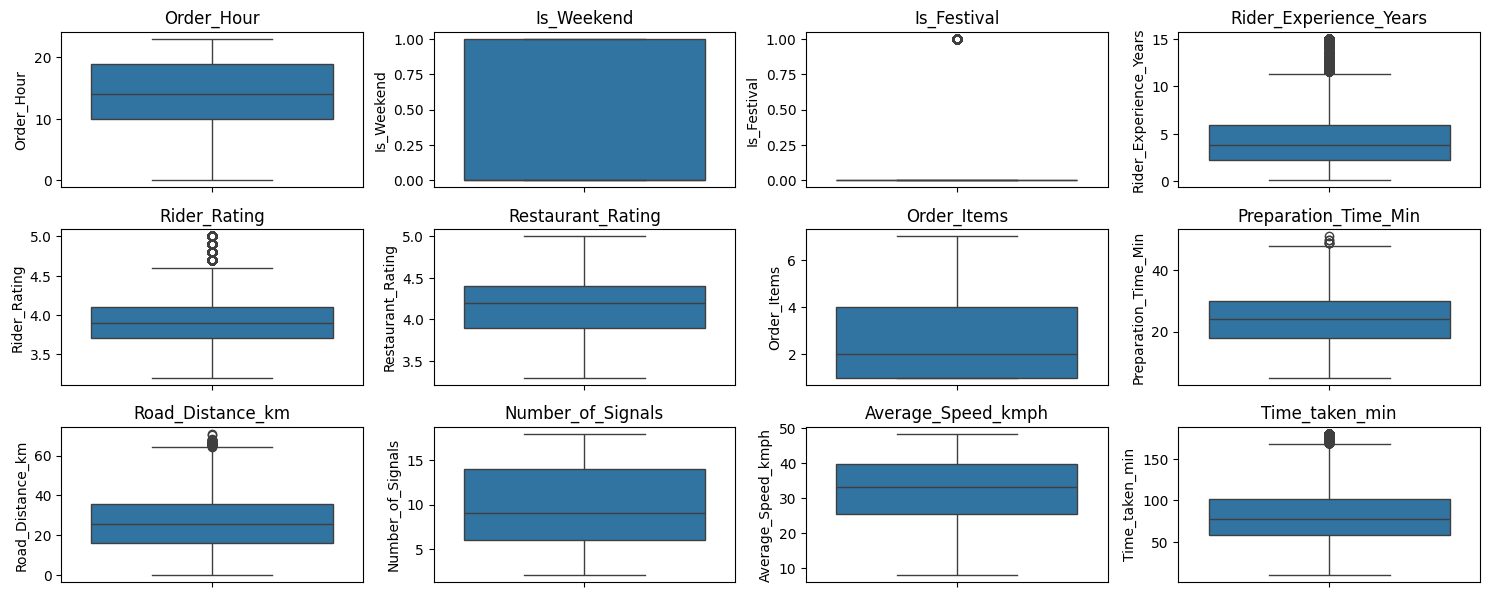

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
df[df["Time_taken_min"] > 150]

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
6,12,Tuesday,0,0,Rain,Commercial,Commercial,Bicycle,2.2,4.0,...,5,Low,13,38.80,Long,Low,10,13.4,Normal,180
13,12,Tuesday,0,0,Clear,Industrial,CBD,Bicycle,1.4,3.7,...,2,High,31,34.79,Long,Low,8,16.2,Normal,162
35,14,Sunday,1,0,Rain,Suburban,CBD,Electric Scooter,3.6,4.0,...,1,Low,23,46.11,Long,Moderate,6,20.9,Priority,156
42,19,Sunday,1,0,Rain,Suburban,CBD,Scooter,2.4,3.3,...,4,Low,21,52.45,Long,High,6,18.6,Priority,180
47,19,Sunday,1,0,Clear,Residential,Industrial,Bicycle,5.5,4.0,...,1,Medium,9,38.12,Long,Moderate,10,13.8,Normal,176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49909,9,Saturday,1,0,Rain,CBD,Residential,Scooter,2.7,3.9,...,3,High,33,28.42,Long,Severe,17,13.7,Normal,170
49925,13,Tuesday,0,0,Rain,Residential,Commercial,Bicycle,4.9,3.9,...,4,Low,14,30.95,Long,Low,6,13.8,Normal,156
49936,16,Tuesday,0,0,Rain,Industrial,Commercial,Bicycle,3.6,3.8,...,3,Medium,36,55.60,Long,Low,7,13.6,Normal,180
49975,10,Friday,0,0,Fog,Residential,Commercial,Bicycle,0.4,3.7,...,5,High,41,45.47,Long,Low,10,14.1,Normal,180


In [ ]:
df[df["Time_taken_min"] > 150][
    ["Road_Distance_km",
     "Preparation_Time_Min",
     "Traffic_Level",
     "Weather",
     "Average_Speed_kmph",
     "Number_of_Signals",
     "Time_taken_min"]
]

,Road_Distance_km,Preparation_Time_Min,Traffic_Level,Weather,Average_Speed_kmph,Number_of_Signals,Time_taken_min
6,38.80,13,Low,Rain,13.4,10,180
13,34.79,31,Low,Clear,16.2,8,162
35,46.11,23,Moderate,Rain,20.9,6,156
42,52.45,21,High,Rain,18.6,6,180
47,38.12,9,Moderate,Clear,13.8,10,176
...,...,...,...,...,...,...,...
49909,28.42,33,Severe,Rain,13.7,17,170
49925,30.95,14,Low,Rain,13.8,6,156
49936,55.60,36,Low,Rain,13.6,7,180
49975,45.47,41,Low,Fog,14.1,10,180


In [ ]:
 print("Rider Experience:")
print(df[df["Rider_Experience_Years"] > 11])

print("\nPreparation Time:")
print(df[df["Preparation_Time_Min"] > 47])

print("\nRoad Distance:")
print(df[df["Road_Distance_km"] > 60])

print("\nDelivery Time:")
print(df[df["Time_taken_min"] > 150])

Rider Experience:
       Order_Hour Day_of_Week  Is_Weekend  Is_Festival Weather  Pickup_Zone  \
4              18      Monday           0            0    Rain   Industrial   
22             17    Thursday           0            0   Clear  Residential   
60             14    Thursday           0            0   Clear     Suburban   
70             21    Saturday           1            0  Cloudy   Commercial   
78             15      Friday           0            0    Rain          CBD   
...           ...         ...         ...          ...     ...          ...   
49760           1   Wednesday           0            0  Cloudy  Residential   
49801           6      Monday           0            0   Clear  Residential   
49849          18      Friday           0            0   Clear          CBD   
49879           1    Saturday           1            0  Cloudy  Residential   
49928          14      Monday           0            0    Rain     Suburban   

      Dropoff_Zone      Vehicle_T

In [ ]:
print(df["Time_taken_min"].max())
print(df["Time_taken_min"].value_counts().sort_index().tail(20))

180
Time_taken_min
161      55
162      49
163      43
164      64
165      38
166      61
167      51
168      42
169      56
170      50
171      60
172      44
173      36
174      50
175      39
176      39
177      49
178      44
179      25
180    1661
Name: count, dtype: int64


In [ ]:
num_features = [
    "Road_Distance_km",
    "Preparation_Time_Min",
    "Average_Speed_kmph",
    "Number_of_Signals",
    "Rider_Experience_Years",
    "Rider_Rating",
    "Restaurant_Rating",
    "Order_Items"
]

### Numerical features vs target

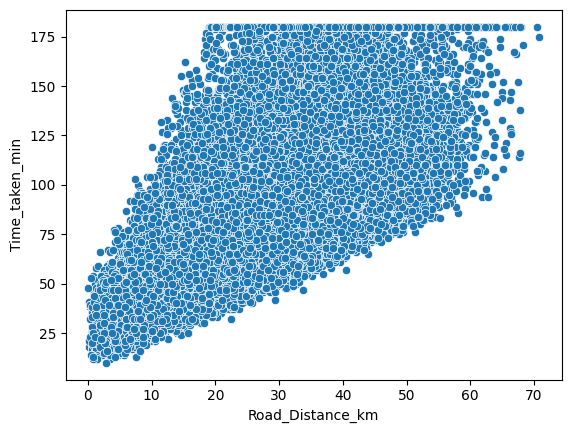

In [ ]:
sns.scatterplot(data=df,x="Road_Distance_km",y="Time_taken_min")
plt.show()

- Around 0–10 km → delivery time is mostly around 15–60 min
- Around 20–40 km → many deliveries are around 50–130 min
- Around 50–70 km → delivery times are frequently 90–170+ min

- Longer delivery distance generally results in longer delivery time.

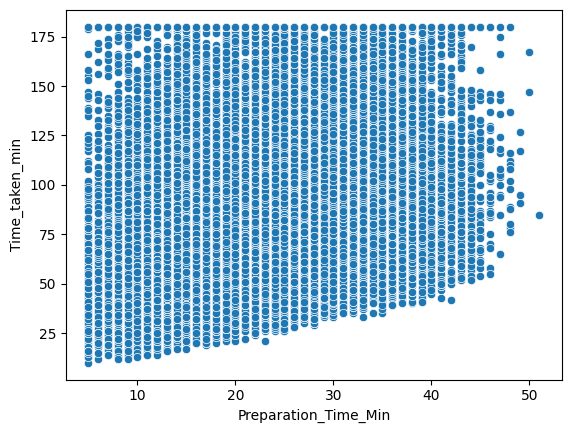

In [ ]:
sns.scatterplot(
    data=df,
    x="Preparation_Time_Min",
    y="Time_taken_min"
)

plt.show()

- Preparation time shows a positive relationship with delivery time.
- This indicates that preparation time contributes to delivery duration but other factors, such as distance, traffic and speed, also play an important role.

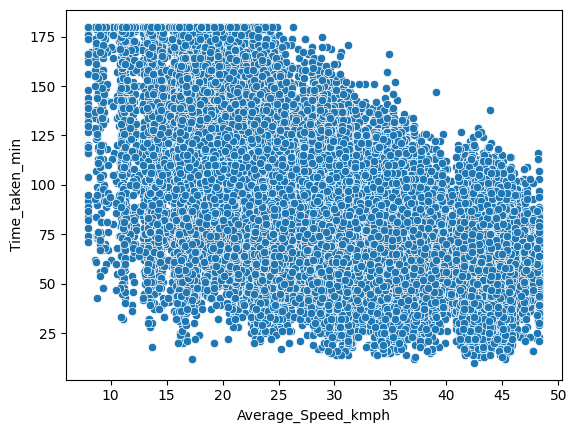

In [ ]:
sns.scatterplot(
    data=df,
    x="Average_Speed_kmph",
    y="Time_taken_min"
)

plt.show()

- As the Avg speed of vechile increase the delivery time decreases.


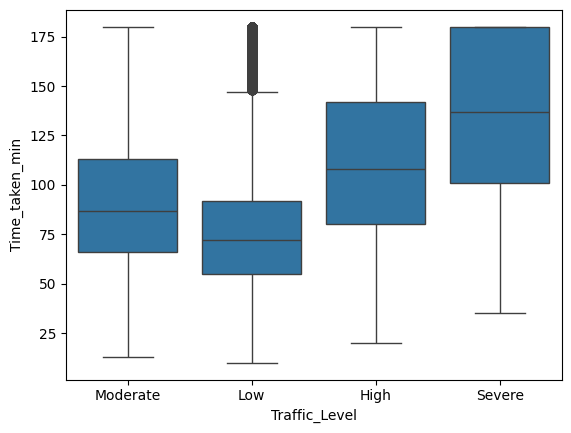

In [ ]:
sns.boxplot(
    data=df,
    x="Traffic_Level",
    y="Time_taken_min"
)

plt.show()

- As traffic severity increases, delivery time generally increases.

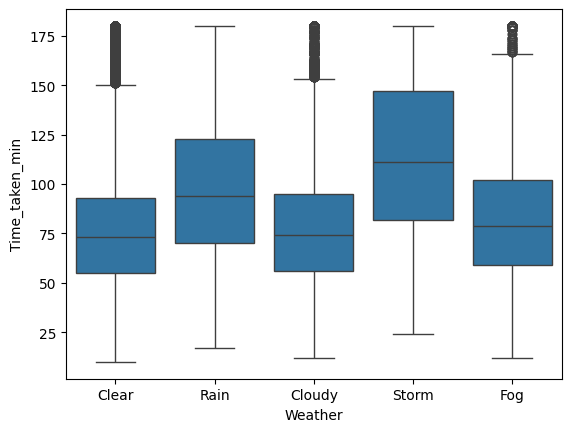

In [ ]:
sns.boxplot(
    data=df,
    x="Weather",
    y="Time_taken_min"
)

plt.show()

- Weather conditions influence food delivery time. Storm and Rain conditions have higher median delivery times compared with Clear and Cloudy conditions, while Fog shows a moderate increase.

<Axes: xlabel='Restaurant_Load', ylabel='Time_taken_min'>

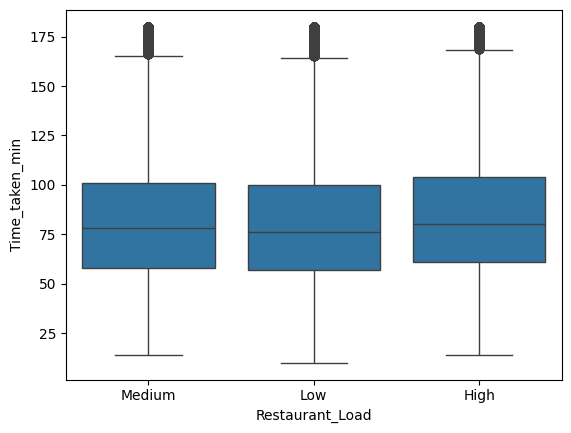

In [ ]:
sns.boxplot(data=df,x='Restaurant_Load',y='Time_taken_min')

- Restaurant load shows only a weak positive relationship with delivery time. Median delivery time increases slightly from Low to Medium and High restaurant load

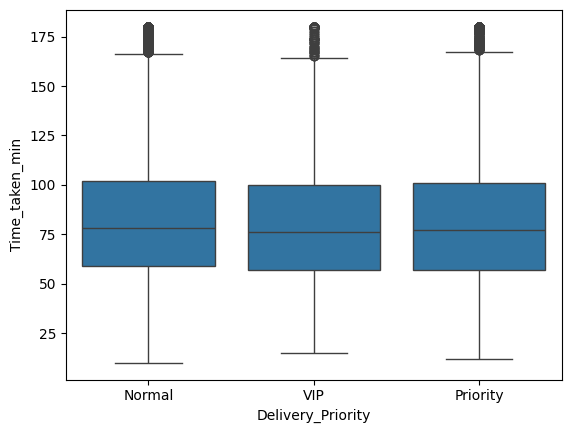

In [ ]:
sns.boxplot(
    data=df,
    x="Delivery_Priority",
    y="Time_taken_min"
)

plt.show()

- Delivery priority appears to have a weak individual relationship with delivery time because the median delivery times for Normal, Priority, and VIP orders are very similar

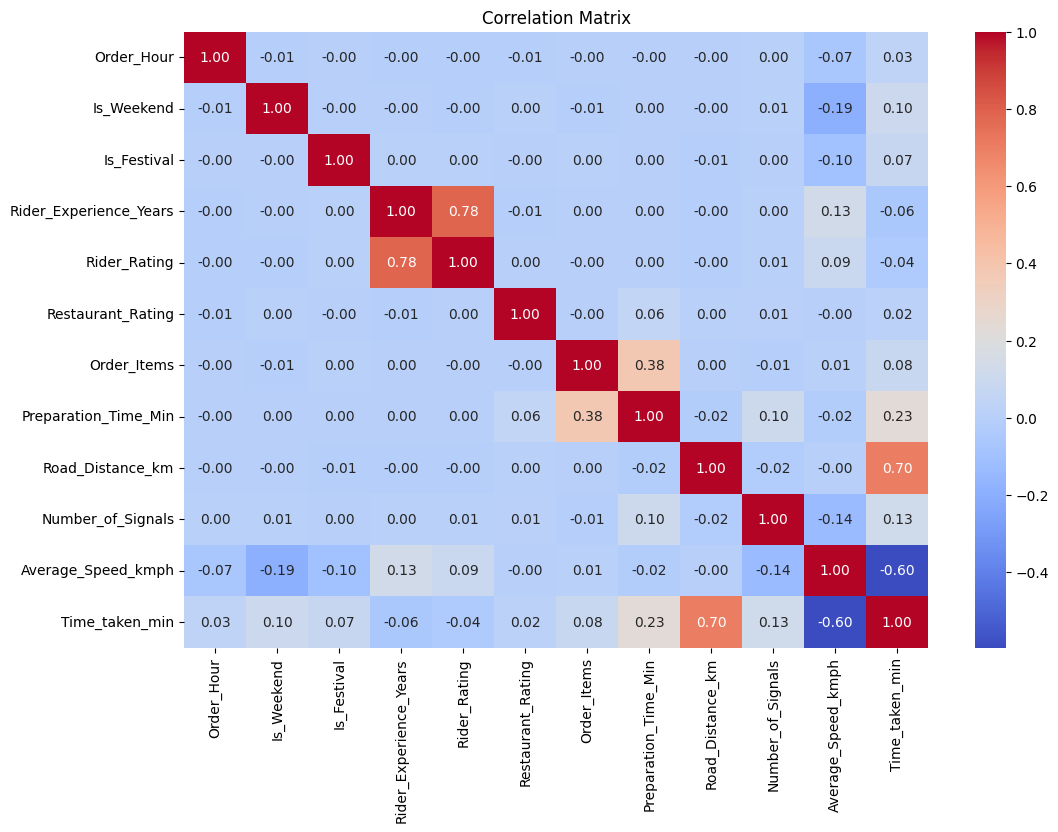

In [ ]:
num_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Feature Preprocessing

In [ ]:
X = df.drop("Time_taken_min", axis=1)
y = df["Time_taken_min"]

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals', 'Average_Speed_kmph']
Categorical: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.select_dtypes(include='number'))
X_test_scaled = scaler.transform(X_test.select_dtypes(include='number'))

In [ ]:
# One Hot Encoding
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(handle_unknown="ignore")
X_train_encoded=encoder.fit_transform(X_train.select_dtypes(include='object'))
X_test_encoded=encoder.transform(X_test.select_dtypes(include='object'))

In [ ]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_scaled,
    X_train_encoded
])

X_test_final = hstack([
    X_test_scaled,
    X_test_encoded
])

In [ ]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_train_encoded:", X_train_encoded.shape)
print("X_train_final:", X_train_final.shape)

print("X_test_final:", X_test_final.shape)

X_train_scaled: (40000, 11)
X_train_encoded: (40000, 48)
X_train_final: (40000, 59)
X_test_final: (10000, 59)


In [ ]:
print(y_train.shape)
print(y_test.shape)

(40000,)
(10000,)


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_final, y_train)

y_pred = knn.predict(X_test_final)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 10.409139999999999
RMSE: 13.932280933142282
R2 Score: 0.8471867735098855


In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 25, 30]

results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_final, y_train)

    y_pred = knn.predict(X_test_final)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([k, mae, rmse, r2])

results

[[1, 14.7834, np.float64(20.213208552825055), 0.6783474393102329],
 [3, 11.216666666666667, np.float64(15.253594111989912), 0.8168272476408972],
 [5, 10.409139999999999, np.float64(13.932280933142282), 0.8471867735098855],
 [7, 10.119428571428571, np.float64(13.509133116192926), 0.8563282235628901],
 [9, 10.015277777777778, np.float64(13.36258887646707), 0.8594283595835976],
 [11, 9.98150909090909, np.float64(13.294656479544363), 0.8608539957593347],
 [15, 9.946953333333333, np.float64(13.297415672060326), 0.860796232633995],
 [20, 9.986820000000002, np.float64(13.362837685162535), 0.8594231247039777],
 [25, 10.04106, np.float64(13.462434448494076), 0.8573198022369395],
 [30, 10.106883333333334, np.float64(13.56167346687798), 0.8552085003994472]]

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["K", "MAE", "RMSE", "R2"]
)
results_df

,K,MAE,RMSE,R2
0,1,14.783400,20.213209,0.678347
1,3,11.216667,15.253594,0.816827
2,5,10.409140,13.932281,0.847187
3,7,10.119429,13.509133,0.856328
4,9,10.015278,13.362589,0.859428
5,11,9.981509,13.294656,0.860854
6,15,9.946953,13.297416,0.860796
7,20,9.986820,13.362838,0.859423
8,25,10.041060,13.462434,0.857320
9,30,10.106883,13.561673,0.855209
